In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import QuantLib as ql

In [2]:
today = ql.Date(17, ql.October, 2016)
ql.Settings.instance().evaluationDate = today

I’ll give to the curve the functional form defined by the Nelson-Siegel model and I’ll fit it to a number of bond.

In [3]:
data = [ (2, 0.02), (4, 0.0225), (6, 0.025), (8, 0.0275),
(10, 0.03), (12, 0.0325), (14, 0.035), (16, 0.0375),
(18, 0.04), (20, 0.0425), (22, 0.045), (24, 0.0475),
(26, 0.05), (28, 0.0525), (30, 0.055)]

In [4]:
calendar = ql.TARGET()
settlement = calendar.advance(today, 3, ql.Days)
quotes = []
helpers = []

for length, coupon in data:
    maturity = calendar.advance(settlement, length, ql.Years)
    schedule = ql.Schedule(
        settlement, maturity, ql.Period(ql.Annual),
        calendar, ql.ModifiedFollowing, ql.ModifiedFollowing,
        ql.DateGeneration.Backward, False)
    
    quote = ql.SimpleQuote(100.0)
    quotes.append(quote)
    helpers.append(
        ql.FixedRateBondHelper(ql.QuoteHandle(quote), 3, 100.0,
                              schedule, [coupon], ql.SimpleDayCounter(),
                              ql.ModifiedFollowing))
    

   # curve = ql.FittedBondDiscountCurve(0, calendar, helpers,
    #                                   ql.SimpleDayCounter(),
     #                                  ql.NelsonSiegelFitting())
    curve = ql.FittedBondDiscountCurve(0, calendar, helpers,
                                       ql.SimpleDayCounter(),
                                       ql.NelsonSiegelFitting())    

Here is a visualization of the curve as discount factors versus time in years:

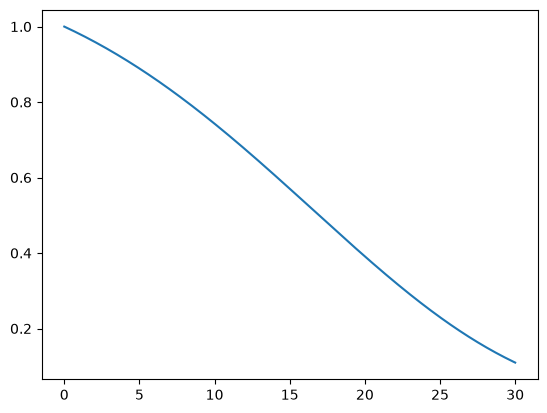

In [5]:
sample_times = np.linspace(0.0, 30.0, 301)
sample_discounts = [curve.discount(t) for t in sample_times]

plt.plot(sample_times, sample_discounts)
plt.show()

Also, here’s a bond priced by discounting its coupons on the curve:

In [7]:
schedule = ql.Schedule(today, calendar.advance(today, 15, ql.Years),
                      ql.Period(ql.Semiannual), calendar,
                      ql.ModifiedFollowing, ql.ModifiedFollowing,
                      ql.DateGeneration.Backward, False
                      )
bond = ql.FixedRateBond(3, 100.0, schedule, [0.04], ql.Actual360())
bond.setPricingEngine(
    ql.DiscountingBondEngine(ql.YieldTermStructureHandle(curve)))
print(bond.cleanPrice())

105.77449622178025


In [8]:
prices = []
def print_price():
    p = bond.cleanPrice()
    prices.append(p)
    print(p)
o = ql.Observer(print_price)
o.registerWith(bond)




In [9]:
quotes[2].setValue(101.0)

105.77449622178025
105.86560413454633


In [10]:
quotes[2].setValue(100.0)

105.86560413454633
105.77449632602422


Now, let’s say the market moves up and, accordingly, all the bonds prices increase to 101. Therefore,
we need to update all the quotes.

In [11]:
prices = []
for q in quotes:
    q.setValue(101.0)

105.77449632602422
105.28388421801475
105.28388421801475
105.2186292238055
105.2186292238055
105.31959063332916
105.31959063332916
105.4878663261018
105.4878663261018
105.68032057288742
105.68032057288742
105.87580396665263
105.87580396665263
106.06201692071569
106.06201692071569
106.23044659597666
106.23044659597666
106.37409219514531
106.37409219514531
106.48708840535757
106.48708840535757
106.56505216839506
106.56505216839506
106.6057074004982
106.6057074004982
106.60980178159524
106.60980178159524
106.58011175261714
106.58011175261714
106.52070688437946


visualize how the price changed.

<h4>Alternatives?</h4>

It is possible to freeze the bond temporarily preventing it from forward notification.

In [13]:
bond.freeze()

Now, notifications won’t be forwarded by the bond and thus won’t reach our observer. In fact, the
following loop won’t print anything.

In [14]:
for q in quotes:
    q.setValue(101.5)

When we restore the bond, it sends a single notification, which triggers only one recalculation and
gives the correct final price.

In [15]:
bond.unfreeze()

106.85839332472605


<h4>Pull, don't push</h4>

let us remove the observer we have in place......and instead create one that raises a flag when it is notified.

In [19]:
flag = {}
flag['status'] = 'down'
def set_flag():
    flag['status'] = 'up'

o=ql.Observer(set_flag)
o.registerWith(bond)

The flag is initially down...

In [20]:
print(flag)

{'status': 'down'}


...and quote changes cause it to be raised.

In [21]:
for q in quotes:
    q.setValue(100.0)

In [22]:
print(flag)

{'status': 'up'}


In [23]:
bond.cleanPrice()

105.77449633968729

Better yet, we can let the instrument do that: let’s remove the second observer, too, and just ask
the instrument for its price after the changes. The instrument keeps track of whether it needs
recalculation, so it doesn’t need us to keep track of it.

In [24]:
del o

In [25]:
for q in quotes:
    q.setValue(101.0)

In [26]:
bond.cleanPrice()

106.52070679688055